<a href="https://colab.research.google.com/github/chickej/localization/blob/main/Copy_of_03_Localization_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 — Localizing Pneumonia with Object Detection
### AIMI High School Internship

Classification answers *"is there pneumonia?"*. **Localization** answers the harder, more useful question: ***where*** is it? We train a model to draw **bounding boxes** around the affected lung regions — the same task a radiologist does when they circle a finding.

The same `dataset_1` chest X-rays, but now we use the **boxes**: every positive (`Target = 1`) row carries an `(x, y, width, height)` region. Negatives have none.

**Faster R-CNN** — a classic two-stage detector that proposes regions, then classifies and refines each into a box. We fine-tune one pretrained on everyday objects.

**IoU** (Intersection-over-Union) between predicted and true boxes, summarized as **precision / recall** at an IoU threshold of 0.5.

## What you'll do in this notebook

1. **Setup** — load data + tools.
2. **Data** — visualize boxes, check the train/val split.
3. **Dataset & Model** — wrap the data for detection, build Faster R-CNN with a fresh head.
4. **Training** — fine-tune the detector and watch loss + IoU.
5. **Evaluate & Submit** — view predicted vs. true boxes and build a Kaggle submission.
6. **(Optional) MedSAM** — turn a detector box into a pixel-level segmentation mask.

# 1. Setup

> Before running: **Runtime → Change runtime type → T4 GPU**. Detection training needs the GPU.

The settings cell holds your only knobs; the setup cell loads everything.

In [ ]:
#@title Notebook settings { display-mode: "form" }
# On Colab, leave these as-is and just run every cell.
# (Automated validation overrides DATA_DIR via papermill — do not rename this cell.)
from pathlib import Path
# Add the `dataset_1` folder to your Google Drive ("My Drive"), then run all cells.
DATA_DIR = Path("/content/drive/MyDrive/dataset_1")

EPOCHS = 2  #@param {type:"integer"}
BATCH_SIZE = 4  #@param {type:"integer"}

In [ ]:
#@title Run setup (imports · data · device) { display-mode: "form" }
import os, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")

# Mount Google Drive so we can read the dataset (skipped automatically off Colab).
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

DATA_DIR = Path(DATA_DIR)
assert DATA_DIR.exists(), f"dataset_1 not found at {DATA_DIR} — add the dataset_1 folder to your Google Drive."
TRAIN_IMG_DIR = DATA_DIR / "train_images"
VAL_IMG_DIR   = DATA_DIR / "val_images"
TEST_IMG_DIR  = DATA_DIR / "test_images"

train_labels = pd.read_csv(DATA_DIR / "train_labels.csv")
val_labels   = pd.read_csv(DATA_DIR / "val_labels.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device} | EPOCHS={EPOCHS}")

Mounted at /content/drive
device=cuda | EPOCHS=2


# 2. Data

## 2.1 Visualize the boxes
Detection labels ARE boxes. Look at a positive case with its ground-truth box drawn — this is what the model must learn to reproduce.

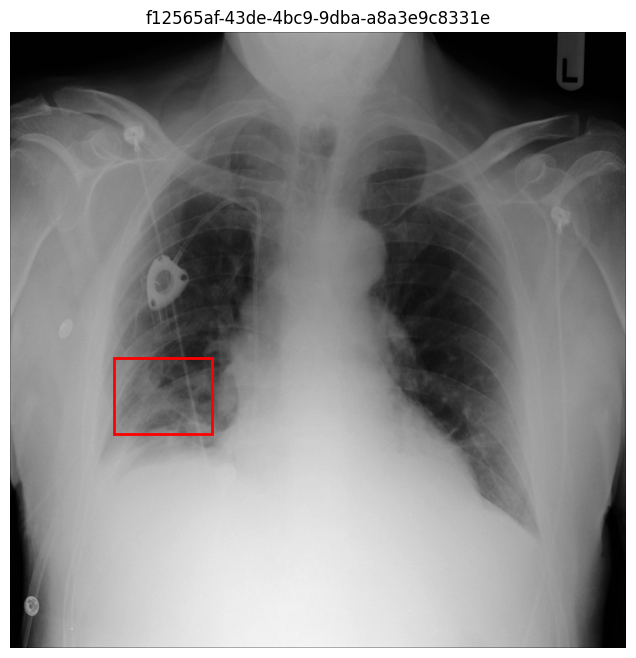

In [ ]:
#@title A random pneumonia case with its box(es) { display-mode: "form" }
pos = train_labels[train_labels["Target"] == 1]
pid = pos.sample(1)["patientId"].iloc[0]
img = Image.open(TRAIN_IMG_DIR / f"{pid}.jpg")
fig, ax = plt.subplots(figsize=(8, 8)); ax.imshow(img, cmap="gray")
for _, r in train_labels[train_labels["patientId"] == pid].iterrows():
    ax.add_patch(plt.Rectangle((r["x"], r["y"]), r["width"], r["height"],
                               edgecolor="red", facecolor="none", linewidth=2))
ax.set_title(f"{pid}"); ax.axis("off"); plt.show()

> **Question:** Classification assigns one label to the whole image. Here we need a *box*. What makes predicting a box (4 numbers + a class) harder than predicting a single yes/no?

## 2.2 The train / val split
We were given train/val splits. The dataset is small enough to train on in full, so we use **all** of it — every positive (the images with boxes to learn from) and every negative.

In [ ]:
train_df = train_labels.reset_index(drop=True)
val_df   = val_labels.reset_index(drop=True)
print(f"train images: {train_df['patientId'].nunique()} | val images: {val_df['patientId'].nunique()}")
print("train positives:", train_df[train_df.Target == 1]["patientId"].nunique())

train images: 3000 | val images: 1500
train positives: 750


# 3. Dataset & Model

## 3.1 A Dataset that returns (image, boxes)
A detection `Dataset` returns each image plus a `target` dict of `boxes` and `labels`. Boxes must be in **`[x1, y1, x2, y2]`** corner format (torchvision's convention) — but our CSV stores **`[x, y, width, height]`**. Converting between them is your first task.

In [ ]:
class Dataset1(Dataset):
    def __init__(self, df, image_dir):
        self.df = df
        self.image_dir = Path(image_dir)
        self.image_ids = df["patientId"].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img = cv2.imread(str(self.image_dir / f"{image_id}.jpg"), cv2.IMREAD_GRAYSCALE)
        img = img.astype(np.float32) / 255.0
        img = np.stack([img] * 3, axis=-1)            # 1 grayscale channel -> 3 (model expects RGB)
        img = torch.from_numpy(img).permute(2, 0, 1)  # HWC -> CHW

        boxes, labels = [], []
        for _, row in self.df[self.df["patientId"] == image_id].iterrows():
            if row["Target"] == 1:
                x, y, w, h = row["x"], row["y"], row["width"], row["height"]
                # Convert (x, y, w, h) -> corner format [x1, y1, x2, y2].
                # TODO: append the box in [x1, y1, x2, y2] format.
                # x1=x, y1=y, x2=x+w, y2=y+h
                boxes.append([x, y, x + w, y + h])  # YOUR CODE HERE
                labels.append(1)                       # class 1 = "pneumonia"

        if boxes:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
        else:                                          # negative image: no objects
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        return img, {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}

def collate(batch):
    return tuple(zip(*batch))                          # detection batches are lists, not stacked tensors

train_dataset = Dataset1(train_df, TRAIN_IMG_DIR)
val_dataset   = Dataset1(val_df,   VAL_IMG_DIR)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate, num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate, num_workers=2)
print("datasets ready:", len(train_dataset), "train /", len(val_dataset), "val")

datasets ready: 3000 train / 1500 val


> **Question:** Why stack the single grayscale channel into **3** channels? Think about what a model pretrained on natural (RGB) photos expects as input.

## 3.2 Faster R-CNN with a fresh head
We load a detector pretrained on the COCO objects (person, car, …) and **replace its classification head** with a 2-class one (background + pneumonia). We also shrink the detector's internal image size to **512** so training fits a T4 — the X-rays are 1024², which is needlessly slow.

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_model(num_classes=2, min_size=512, max_size=512):
    # min_size/max_size shrink the 1024x1024 inputs internally -> ~4x faster on a T4.
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT", min_size=min_size, max_size=max_size)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model.to(device)

model = build_model()
print("Faster R-CNN ready (2 classes: background + pneumonia)")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 154MB/s]


Faster R-CNN ready (2 classes: background + pneumonia)


> **Question:** The pretrained head predicts 90 COCO categories. Why must we replace it before training on pneumonia?

# 4. Training

## 4.1 Train / validate functions
Faster R-CNN is unusual: **in training mode it returns the losses itself** (a dict of region-proposal + box + classification losses). We just **sum them** and backprop. There's no separate `criterion` — the loss is built into the model.

In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for images, targets in tqdm(loader, desc="  training", leave=False):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        # In train mode the model returns a dict of losses. Combine + optimize:
        # TODO: the five-ish moves of a detection training step.
        # loss_dict = model(images, targets)   # returns a dict of losses
        # loss = sum(loss_dict.values())       # add them up
        # optimizer.zero_grad(); loss.backward(); optimizer.step()
        loss_dict = model(images, targets) #
        loss = sum(loss_dict.values())
        optimizer.zero_grad();
        loss.backward()
        optimizer.step()
        # loss = ...  # YOUR CODE HERE
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def validate_one_epoch(model, loader):
    model.train()                                # keep train mode so the model still returns losses
    total = 0.0
    for images, targets in tqdm(loader, desc="  validating", leave=False):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        total += sum(model(images, targets).values()).item()
    return total / len(loader)

## 4.2 Measuring detection quality — IoU
**IoU = intersection area ÷ union area** of two boxes (1.0 = perfect overlap, 0 = none). A prediction counts as a true positive if its IoU with a real box is ≥ 0.5. Implement IoU, then we wrap it into a precision/recall evaluator.

In [ ]:
def compute_iou(a, b):
    """IoU of two [x1, y1, x2, y2] boxes."""
    # Intersection rectangle:
    # TODO: compute the intersection area of boxes a and b.
    # the overlap's left/top = max of the two lefts/tops
    # the overlap's right/bottom = min of the two rights/bottoms
    # inter = max(0, right-left) * max(0, bottom-top)
    x_left = max(a[0], b[0])
    y_top = max(a[1], b[1])
    x_right = min(a[2], b[2])
    y_bottom = min(a[3], b[3])

    inter_width = max(0, x_right - x_left)
    inter_height = max(0, y_bottom - y_top)
    #inter = ...  # YOUR CODE HERE
    inter = inter_width * inter_height

    areaA = (a[2] - a[0]) * (a[3] - a[1])
    areaB = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (areaA + areaB - inter + 1e-6)     # union = areaA + areaB - inter

@torch.no_grad()
def evaluate_with_iou(model, loader, score_threshold=0.5, iou_threshold=0.5):
    model.eval()                                       # eval mode -> model returns predictions, not losses
    tp = total_preds = total_truths = 0
    ious = []
    for images, targets in tqdm(loader, desc="  evaluating", leave=False):
        outputs = model([img.to(device) for img in images])
        for output, target in zip(outputs, targets):
            pred = output["boxes"].cpu().numpy()[output["scores"].cpu().numpy() > score_threshold]
            gt = target["boxes"].numpy()
            total_preds += len(pred); total_truths += len(gt)
            for pb in pred:
                best = max([compute_iou(pb, g) for g in gt], default=0)
                if best >= iou_threshold:
                    tp += 1
                if best > 0:
                    ious.append(best)
    precision = tp / total_preds if total_preds else 0
    recall = tp / total_truths if total_truths else 0
    return precision, recall, (np.mean(ious) if ious else 0.0)

> **Question:** We never wrote a loss function for the boxes. Where does the box-regression loss actually come from?

## 4.3 Train the detector
Fine-tune with a **small learning rate** (`1e-5`) — the backbone is already good; we only nudge it. Watch the loss fall and IoU rise.

In [ ]:
train_losses, val_losses, precisions, recalls, ious = [], [], [], [], []

optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-5)
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    tl = train_one_epoch(model, train_loader, optimizer)
    vl = validate_one_epoch(model, val_loader)
    p, r, miou = evaluate_with_iou(model, val_loader)
    train_losses.append(tl); val_losses.append(vl)
    precisions.append(p); recalls.append(r); ious.append(miou)
    print(f"  train loss {tl:.4f} | val loss {vl:.4f} | precision {p:.3f} | recall {r:.3f} | IoU {miou:.3f}")


Epoch 1/2


  training:   0%|          | 0/750 [00:00<?, ?it/s]

  validating:   0%|          | 0/375 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/375 [00:00<?, ?it/s]

  train loss 0.0898 | val loss 0.0892 | precision 0.414 | recall 0.492 | IoU 0.560

Epoch 2/2


  training:   0%|          | 0/750 [00:00<?, ?it/s]

  validating:   0%|          | 0/375 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/375 [00:00<?, ?it/s]

  train loss 0.0765 | val loss 0.0855 | precision 0.325 | recall 0.634 | IoU 0.542


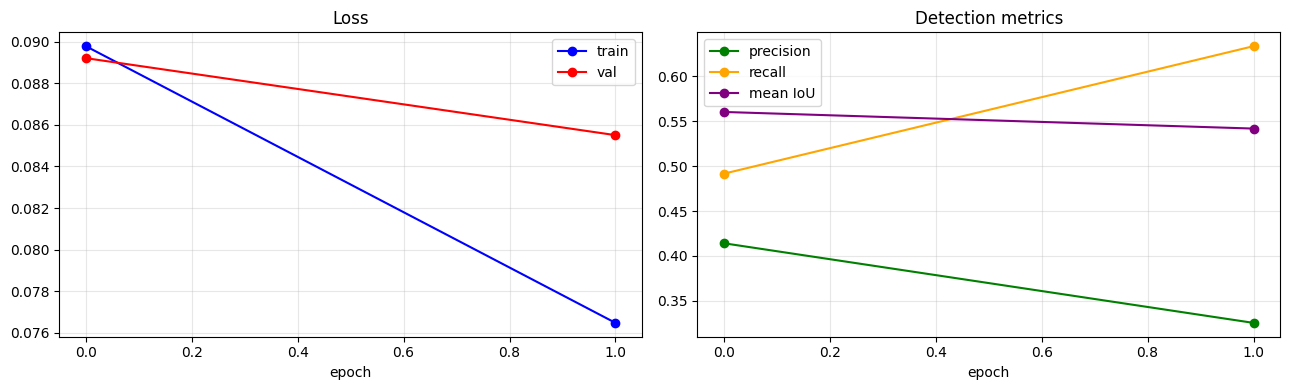

In [ ]:
#@title Loss & metric curves { display-mode: "form" }
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(train_losses, "b-o", label="train"); ax[0].plot(val_losses, "r-o", label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(precisions, "g-o", label="precision"); ax[1].plot(recalls, "orange", marker="o", label="recall")
ax[1].plot(ious, "purple", marker="o", label="mean IoU")
ax[1].set_title("Detection metrics"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

> **Tip:** Want live curves? Colab supports TensorBoard — `%load_ext tensorboard` then log with a `SummaryWriter`. We keep static matplotlib plots here so the notebook stays simple and runs headless.

# 5. Evaluate & Submit

## 5.1 Predicted vs. ground-truth boxes
Red = the model's prediction, green dashed = the truth. This is the most honest way to judge a detector — does it box the right region?

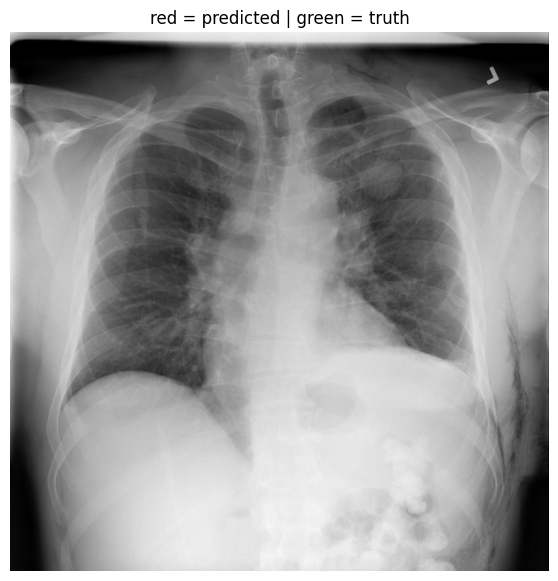

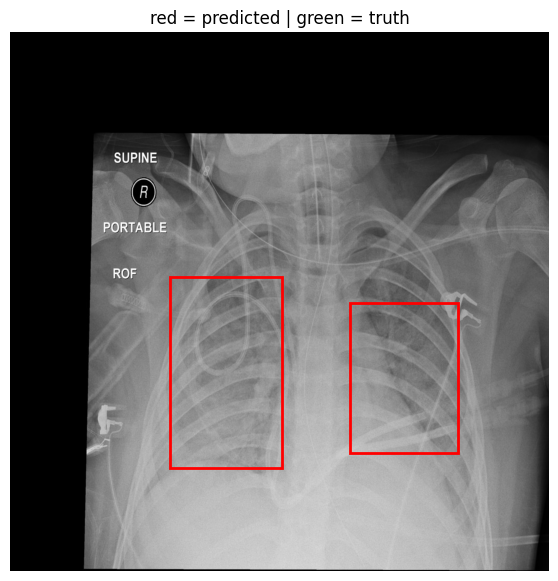

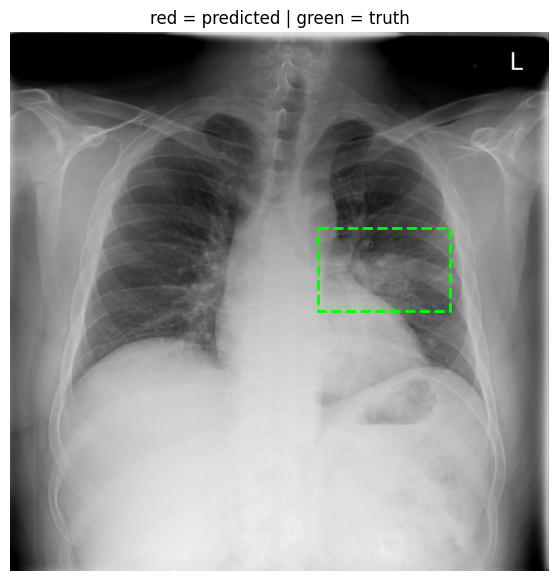

In [ ]:
#@title Predictions on random validation images { display-mode: "form" }
score_threshold = 0.65  #@param {type:"slider", min:0.1, max:0.9, step:0.05}
model.eval()
for idx in random.sample(range(len(val_dataset)), min(3, len(val_dataset))):
    image, target = val_dataset[idx]
    with torch.no_grad():
        out = model(image.to(device).unsqueeze(0))[0]
    pred = out["boxes"].cpu().numpy()[out["scores"].cpu().numpy() > score_threshold]
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(image.permute(1, 2, 0).numpy(), cmap="gray")
    for x1, y1, x2, y2 in pred:
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="red", facecolor="none", lw=2))
    for x1, y1, x2, y2 in target["boxes"].numpy():
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="lime", facecolor="none", lw=2, ls="--"))
    ax.set_title("red = predicted | green = truth"); ax.axis("off"); plt.show()

> **Question:** If the model's box is shifted slightly off the truth, is that "wrong"? How does the IoU threshold decide — and is 0.5 the only reasonable choice?

## 5.2 Build the Kaggle submission
Run the detector on the held-out **test** images (no labels) and write predictions in the leaderboard format: `score x y width height` per box.

In [ ]:
@torch.no_grad()
def build_submission(model, test_img_dir, threshold=0.5, limit=None):
    model.eval()
    ids = sorted(f[:-4] for f in os.listdir(test_img_dir) if f.endswith(".jpg") and not f.startswith("._"))
    if limit:
        ids = ids[:limit]
    rows = []
    for image_id in tqdm(ids, desc="predicting test"):
        img = cv2.imread(str(Path(test_img_dir) / f"{image_id}.jpg"), cv2.IMREAD_GRAYSCALE).astype("float32") / 255.0
        img = torch.from_numpy(img).unsqueeze(0).repeat(3, 1, 1).to(device).unsqueeze(0)
        out = model(img)[0]
        parts = []
        for (x1, y1, x2, y2), s in zip(out["boxes"].cpu().numpy(), out["scores"].cpu().numpy()):
            if s >= threshold:
                parts.append(f"{s:.4f} {x1:.1f} {y1:.1f} {x2 - x1:.1f} {y2 - y1:.1f}")
        rows.append({"patientId": image_id, "PredictionString": " ".join(parts)})
    return pd.DataFrame(rows)

submission_df = build_submission(model, TEST_IMG_DIR, threshold=0.5, limit=None)
submission_df.to_csv("submission.csv", index=False)
print("wrote submission.csv")
submission_df.head()

predicting test:   0%|          | 0/1500 [00:00<?, ?it/s]

KeyboardInterrupt: 

On Colab, download `submission.csv` from the file browser (`/content/submission.csv`) and upload it to the Kaggle leaderboard.

Try it: the score `threshold` trades precision for recall. Sweep it (0.3 → 0.7), re-run 5.1, and decide which value you'd submit — and *why*.

# 6. (Optional) Exploring MedSAM — from a box to a mask

Your detector draws a **box** around pneumonia. **MedSAM** can take that box and return a **pixel-level mask** of the opacity inside it — a finer kind of localization, and a nice example of *composing* two models: a detector that finds *where*, and a segmenter that decides *which pixels*.

**What is MedSAM?** It builds on **SAM** (the *Segment Anything Model*), a foundation model for image segmentation that you steer with a **prompt** — a point or a box — instead of retraining it per task. SAM was trained on everyday photos, so it can stumble on medical scans. **MedSAM** is SAM **fine-tuned on ~1.5 million medical image–mask pairs** spanning many modalities (X-ray, CT, MRI, ultrasound, pathology, …), which specializes it for clinical images. It is driven specifically by **bounding-box prompts** — exactly what this notebook produces.

**How it works** — three pieces:
1. an **image encoder** (a Vision Transformer) embeds the whole image *once*;
2. a **prompt encoder** turns your box into an embedding that says *look here*;
3. a lightweight **mask decoder** fuses the two and outputs a segmentation mask.

Because the heavy image-encoding happens once, you can re-prompt the same image with different boxes cheaply. Below you load MedSAM, then **build the box prompt yourself**.

> MedSAM (Ma et al., *Nature Communications*, 2024) — original code at `bowang-lab/MedSAM`. We use the Hugging Face port so it plugs straight into the `transformers` library you already have.

In [ ]:
#@title Load MedSAM (downloads ~375 MB the first time) { display-mode: "form" }
from transformers import SamModel, SamProcessor

MEDSAM_ID = "flaviagiammarino/medsam-vit-base"      # SAM fine-tuned for medical images
medsam_model = SamModel.from_pretrained(MEDSAM_ID).to(device).eval()
medsam_processor = SamProcessor.from_pretrained(MEDSAM_ID)
print("MedSAM loaded on", device)

## 6.1 Your turn: prompt MedSAM with a box

MedSAM's processor wants the box prompt as a **nested list**, `input_boxes`, shaped `[image][box][4]`:

```python
input_boxes = [[[x_min, y_min, x_max, y_max]]]
```

The outermost list is the batch (one image here), the next level is the boxes for that image (one box here), and the four numbers are the corners — the same `[x1, y1, x2, y2]` format your detector already outputs. **Your job is to wrap a box into `input_boxes`** inside the helper below.

We then segment the same X-ray from **two** prompts side by side — the **ground-truth** box and **your detector's predicted** box — so you can separate two different questions:

- *How good is MedSAM?* → judge the **ground-truth-box** mask (a clean box in, so the mask reflects MedSAM alone).
- *How good is my detector→MedSAM pipeline?* → judge the **predicted-box** mask (your detector's errors flow through, which is what you'd actually deploy).

In [ ]:
#@title Run MedSAM: ground-truth box vs. your detector's box { display-mode: "form" }
import numpy as np
from PIL import Image

# Pick a positive validation image (one that actually has pneumonia to segment).
pos_val_ids = val_df[val_df["Target"] == 1]["patientId"].unique()
image_id = pos_val_ids[0]
idx = list(val_dataset.image_ids).index(image_id)
image, target = val_dataset[idx]

# MedSAM's processor expects an RGB image; turn the CHW [0,1] tensor into a PIL image.
img_np = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
pil_image = Image.fromarray(img_np)

def medsam_mask(box):
    """Segment the region inside `box` ([x1, y1, x2, y2]) with MedSAM -> boolean mask."""
    # YOUR TURN: wrap `box` into the nested list the processor expects.
    #   input_boxes shape is [image][box][4]:  [[[x_min, y_min, x_max, y_max]]]
    input_boxes = ...  # YOUR CODE HERE
    inputs = medsam_processor(pil_image, input_boxes=input_boxes, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = medsam_model(**inputs, multimask_output=False)
    prob = medsam_processor.image_processor.post_process_masks(
        outputs.pred_masks.sigmoid().cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu(),
        binarize=False,
    )[0][0, 0].numpy()
    return prob > 0.5

# Box 1 = the ground-truth box; Box 2 = your detector's top-scoring prediction.
gt_box = [float(v) for v in target["boxes"][0].tolist()]
model.eval()
with torch.no_grad():
    det = model(image.to(device).unsqueeze(0))[0]
pred_box = [float(v) for v in det["boxes"][det["scores"].argmax()].cpu().tolist()] if len(det["boxes"]) else None

panels = [("ground-truth box", gt_box)]
if pred_box is not None:
    panels.append(("your detector's box", pred_box))
else:
    print("Detector found no box on this image — showing the ground-truth prompt only.")

# Segment from each prompt and overlay the mask (red) + the prompt box (yellow), side by side.
fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 7), squeeze=False)
for ax, (label, box) in zip(axes[0], panels):
    mask = medsam_mask(box)
    ax.imshow(pil_image, cmap="gray")
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.45)
    x1, y1, x2, y2 = box
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="yellow", facecolor="none", lw=2))
    ax.set_title(f"mask (red) from {label} (yellow)"); ax.axis("off")
plt.tight_layout(); plt.show()

**What to look for:** if the two masks disagree, the gap is your **detector's** error (the box was off), not MedSAM's — the ground-truth-box mask is MedSAM's best case on this image.

**Your turn — a few more things to try:**

- Step through several positive validation images (change `pos_val_ids[0]`) and see where the predicted-box mask drifts from the ground-truth one.
- Compare the **mask area** to the **box area** — how much of the box is actually opacity?
- MedSAM expects a *tight* box. Feed `medsam_mask` a deliberately loose box and watch the mask degrade — prompt quality matters.